## Examen Restaurantes

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Ingeniería de Datos

In [266]:
users = pd.read_csv('datos/users.csv')
usercuisine = pd.read_csv('datos/usercuisine.csv')
ratings = pd.read_csv('datos/ratings.csv')
restaurants = pd.read_csv('datos/restaurants.csv')
hours = pd.read_csv('datos/hours.csv')
cuisines = pd.read_csv('datos/cuisine.csv')
payment_methods = pd.read_csv('datos/payment_methods.csv')
parking = pd.read_csv('datos/parking.csv')
users.head()


,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


### Análisis users

In [3]:
#users.budget = users.budget.map({'low': 1, 'medium': 2, 'high': 3, '?': 0})
users['age'] = 2025 - users['birth_year']

In [4]:
users_cuisine = users.join(usercuisine.set_index('userID'), on='userID')
users_cuisine[:10]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,interest,personality,religion,activity,color,weight,budget,height,age,Rcuisine
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,variety,thrifty-protector,none,student,black,69,medium,1.77,36,American
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,...,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87,35,Mexican
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,...,none,hard-worker,Catholic,student,blue,60,low,1.69,36,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bakery
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Breakfast-Brunch
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Japanese
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Contemporary
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bagels
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Cafe-Coffee_Shop


In [5]:
users_ratings = users.join(ratings.set_index('userID'), on='userID')
users_ratings[:5]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,activity,color,weight,budget,height,age,placeID,rating,food_rating,service_rating
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132830,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132825,2,2,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135085,0,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135040,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135039,1,1,1


In [6]:
users_ratings['frequency'] =users_ratings.groupby(['userID','placeID'])['rating'].transform('count')
users_ratings = users_ratings.rename(columns={'longitude':'longitude_user','latitude':'latitude_user'})
    
users_ratings.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,color,weight,budget,height,age,placeID,rating,food_rating,service_rating,frequency
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132830,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132825,2,2,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135085,0,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135040,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135039,1,1,1,1


In [7]:
df = users_ratings.join(restaurants.set_index('placeID'), on='placeID').head()

In [8]:
from geopy.distance import geodesic

df['dist_km'] = df.apply(lambda row: geodesic((row.latitude_user, row.longitude_user), 
                                              (row.latitude, row.longitude)).kilometers, axis=1)
df.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,dist_km
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,closed,none,4.203769
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,open,none,0.930770
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none,1.261535
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,no_accessibility,high,?,familiar,f,closed,none,1.056110
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,section,informal,no_accessibility,low,?,familiar,f,closed,none,0.768673


In [9]:
df.dtypes

userID               object
latitude_user       float64
longitude_user      float64
smoker               object
drink_level          object
dress_preference     object
ambience             object
transport            object
marital_status       object
hijos                object
birth_year            int64
interest             object
personality          object
religion             object
activity             object
color                object
weight                int64
budget               object
height              float64
age                   int64
placeID               int64
rating                int64
food_rating           int64
service_rating        int64
frequency             int64
latitude            float64
longitude           float64
the_geom_meter       object
name                 object
address              object
city                 object
state                object
country              object
fax                  object
zip                  object
alcohol             

In [10]:
df.corr(numeric_only=True)

,latitude_user,longitude_user,birth_year,weight,height,age,placeID,rating,food_rating,service_rating,frequency,latitude,longitude,dist_km
latitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
placeID,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-0.654937,-0.613446,NaN,NaN,-0.429463,-0.442655,-0.581558
rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.654937,1.000000,0.790569,NaN,NaN,-0.192874,-0.008172,-0.081089
food_rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.613446,0.790569,1.000000,NaN,NaN,0.114611,-0.409938,-0.276534
service_rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


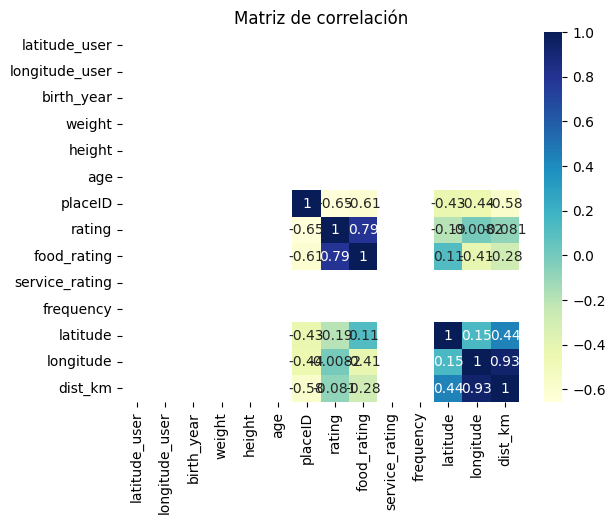

In [11]:
# Matriz de correlación
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis restaurantes

In [267]:
#Nuevas variiables (meadias de rating, numero de opciones de cocina y pago)
ratings_mean = ratings.groupby('placeID')[['rating','food_rating','service_rating']].mean()
rest_rating = restaurants.join(ratings_mean, on='placeID').rename(columns={'rating':'rating_mean',
                                                                           'food_rating':'food_rating_mean',
                                                                           'service_rating':'service_rating_mean'})
#Opciones de cocina
cuisines = cuisines.groupby('placeID')['Rcuisine'].count()
rest_rating = rest_rating.join(cuisines, on='placeID').rename(columns={'Rcuisine':'cuisines_options'})
#Opciones de pago
payment_options = payment_methods.groupby('placeID')['Rpayment'].count()
rest_rating = rest_rating.join(payment_options, on='placeID').rename(columns={'Rpayment': 'payment_options'})
#join con ratings originales
rest_rating = rest_rating.join(ratings.set_index('placeID'), on='placeID')
rest_rating = rest_rating.join(parking.set_index('placeID'), on='placeID')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,rating_mean,food_rating_mean,service_rating_mean,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.6,1.0,NaN,U1093,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.6,1.0,NaN,U1066,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.6,1.0,NaN,U1040,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.6,1.0,NaN,U1110,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.6,1.0,NaN,U1121,2,2,2,none


In [268]:
#Mapear variables categóricas a discretas
rest_rating['price'] = rest_rating.price.map({'low': 1, 'medium': 2, 'high': 3})
rest_rating['franchise'] = rest_rating.franchise.map({'t': 0, 'f': 1})
rest_rating['parking'] = rest_rating.parking_lot.apply(lambda val: 0 if val == 'none' else 1)

#### Target

In [273]:
rest_rating.dtypes

placeID                  int64
latitude               float64
longitude              float64
the_geom_meter          object
name                    object
address                 object
city                    object
state                   object
country                 object
fax                     object
zip                     object
alcohol                 object
smoking_area            object
dress_code              object
accessibility           object
price                    int64
url                     object
Rambience               object
franchise                int64
area                    object
other_services          object
rating_mean            float64
food_rating_mean       float64
service_rating_mean    float64
cuisines_options       float64
payment_options        float64
userID                  object
rating                   int64
food_rating              int64
service_rating           int64
parking_lot             object
parking                  int64
dtype: o

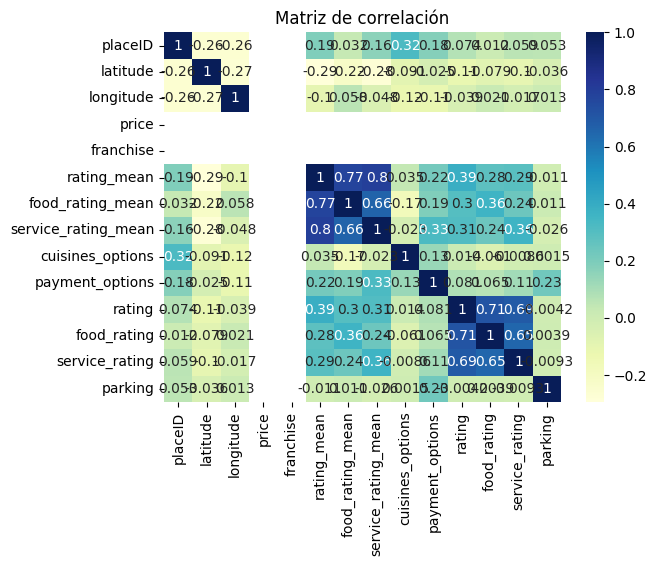

In [265]:
# Matriz de correlación
corr = rest_rating.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis Nulls y Outliers

In [269]:
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,food_rating_mean,service_rating_mean,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.0,NaN,U1093,2,2,2,none,0
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.0,NaN,U1066,1,1,1,none,0
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.0,NaN,U1040,1,1,1,none,0
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.0,NaN,U1110,2,2,2,none,0
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,1.0,NaN,U1121,2,2,2,none,0


In [271]:
for col in rest_rating:
    if rest_rating[col].isnull().sum() > 0:
        print(f"{col}: {rest_rating[col].isnull().sum()}")

cuisines_options: 288
payment_options: 100


In [272]:
rest_rating[rest_rating['cuisines_options'].isnull()]

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,food_rating_mean,service_rating_mean,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,0.250000,0.250000,NaN,3.0,U1126,0,0,0,yes,1
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,0.250000,0.250000,NaN,3.0,U1022,0,0,0,yes,1
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,0.250000,0.250000,NaN,3.0,U1105,0,0,0,yes,1
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,0.250000,0.250000,NaN,3.0,U1001,1,1,1,yes,1
9,135082,22.151448,-100.915099,0101000020957F0000A29FAF95CD4958C1FEEEBB73A991...,la Estrella de Dimas,Villa de Pozos 192 Villa de Pozos,San Luis Potosi,SLP,Mexico,?,...,0.777778,0.666667,NaN,1.0,U1088,2,2,2,none,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,135062,22.153703,-100.979033,0101000020957F0000D177B9CFB14758C162A211E1C2A3...,Restaurante El Cielo Potosino,Julian de Los Reyes 400 Centro,San Luis Potosi,SLP,Mexico,?,...,1.238095,1.095238,NaN,1.0,U1058,2,2,2,yes,1
129,132877,22.135364,-100.934948,0101000020957F000090735015B84B58C1AF0DC0414698...,sirloin stockade,?,?,?,?,?,...,0.750000,1.000000,NaN,NaN,U1047,0,0,0,none,0
129,132877,22.135364,-100.934948,0101000020957F000090735015B84B58C1AF0DC0414698...,sirloin stockade,?,?,?,?,?,...,0.750000,1.000000,NaN,NaN,U1111,1,1,1,none,0
129,132877,22.135364,-100.934948,0101000020957F000090735015B84B58C1AF0DC0414698...,sirloin stockade,?,?,?,?,?,...,0.750000,1.000000,NaN,NaN,U1015,1,1,2,none,0
